In [1]:
'''
Imports and loading dataset.
'''

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from scipy.ndimage import sobel

ROOT = Path("Bird Speciees Dataset")  
IMAGE_SIZE = (224,224)

paths = sorted(
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if not paths:
    raise FileNotFoundError(f"No images found in {ROOT.resolve()}")

print(f"{len(paths)} images")

811 images


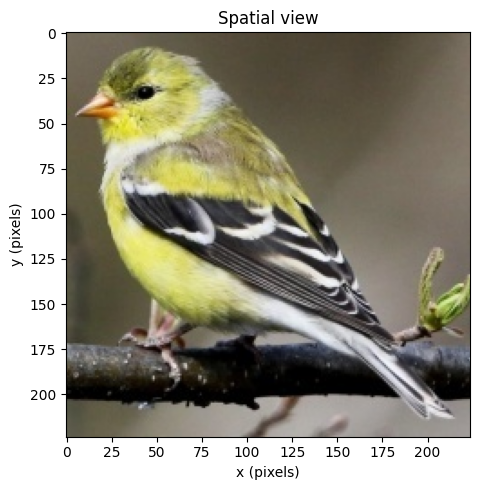

In [2]:
arr = np.asarray(Image.open(paths[0]).convert("RGB"))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(arr)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Spatial view")
plt.tight_layout()
plt.show()

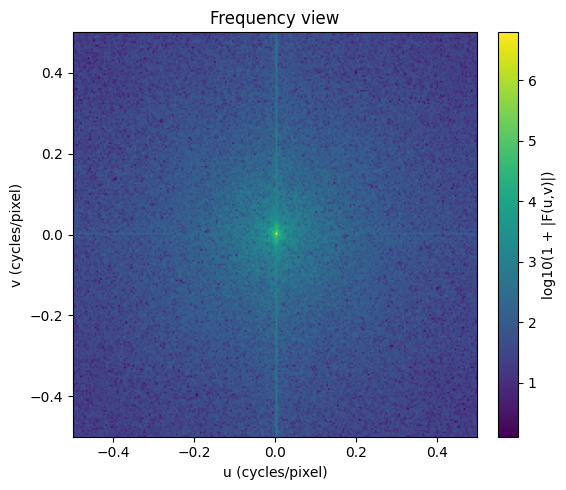

In [3]:
# Mean image across the dataset
mean_img = np.zeros((*IMAGE_SIZE, 3), dtype=np.float64)
for p in paths:
    mean_img += np.asarray(Image.open(p).convert("RGB"), dtype=np.float64)
mean_img /= len(paths)
gray = mean_img.mean(axis=2)

# 2-D FFT
F = np.fft.fftshift(np.fft.fft2(gray))
mag = np.log10(1 + np.abs(F))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    mag,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
    cmap="viridis",
)
ax.set_xlabel("u (cycles/pixel)")
ax.set_ylabel("v (cycles/pixel)")
ax.set_title("Frequency view")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log10(1 + |F(u,v)|)")
plt.tight_layout()
plt.show()

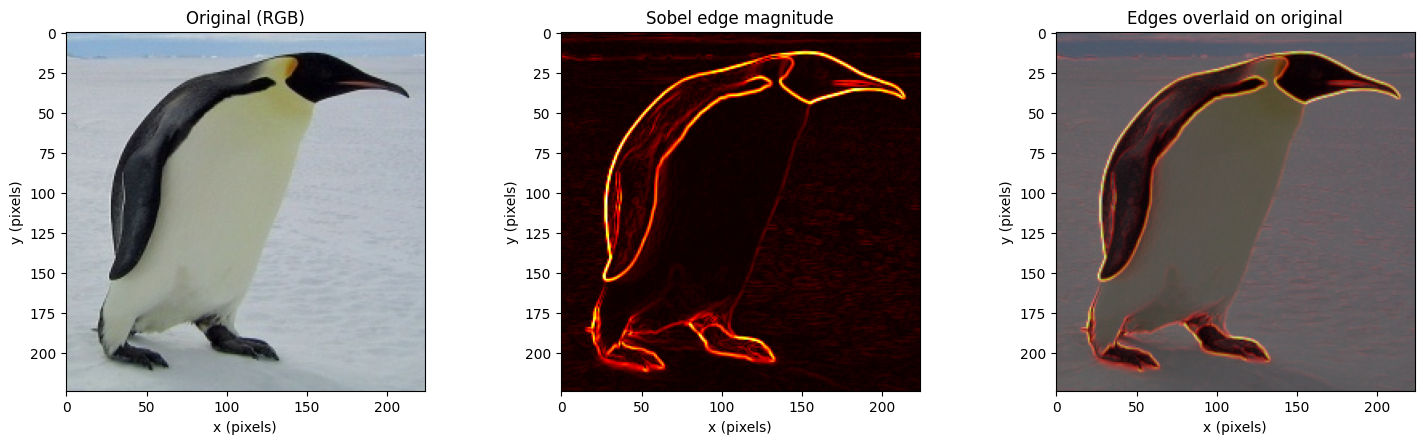

In [ ]:


paths = [p for p in ROOT.rglob("*")
         if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]

# One image — load RGB and grayscale
used_image = paths[560]  # Change this index to use a different image
rgb  = np.asarray(Image.open(used_image).convert("RGB"))
gray = np.asarray(Image.open(used_image).convert("L"), dtype=np.float64)

# Sobel edges
gx = sobel(gray, axis=1)
gy = sobel(gray, axis=0)
mag = np.hypot(gx, gy)

# Show original, edges, and overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(rgb)
axes[0].set_title("Original (RGB)")
axes[0].set_xlabel("x (pixels)"); axes[0].set_ylabel("y (pixels)")

axes[1].imshow(mag, cmap="hot")
axes[1].set_title("Sobel edge magnitude")
axes[1].set_xlabel("x (pixels)"); axes[1].set_ylabel("y (pixels)")

axes[2].imshow(rgb)
axes[2].imshow(mag, cmap="hot", alpha=0.5)
axes[2].set_title("Edges overlaid on original")
axes[2].set_xlabel("x (pixels)"); axes[2].set_ylabel("y (pixels)")

plt.tight_layout()
plt.show()

### How much signal can be removed before one cannot identify the bird?

To determine this, first the signal of an average of all images of each bird will be calculated. 

In [ ]:

# All iamges shall be grayscale, then create the per-bird average images.

